In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    cross_val_predict
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    make_scorer, 
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from pathlib import Path

import os

DATA_DIR = Path(
    "/Users/suhanibhanvadia/Documents/Projects:Research/09142026PROJECT/EEG_data"
)
RANDOM_STATE = 42
BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30)
}

In [84]:
participants = pd.read_csv(
    DATA_DIR / "participants.tsv",
    sep="\t"
)

print("Participants:", len(participants))
print("\nGroup distribution:")
print(participants["Group"].value_counts())

participants.head()

Participants: 88

Group distribution:
Group
A    36
C    29
F    23
Name: count, dtype: int64


,participant_id,Gender,Age,Group,MMSE
0,sub-001,F,57,A,16
1,sub-002,F,78,A,22
2,sub-003,M,70,A,14
3,sub-004,F,67,A,20
4,sub-005,M,70,A,22


In [85]:
preprocessed_files = sorted(
    (DATA_DIR / "derivatives").glob(
        "sub-*/eeg/*_eeg.set"
    )
)

<RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~43.5 MiB, data loaded>
Sampling freq: 500.0 Hz
Duration: 599.798 seconds
Channels: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']


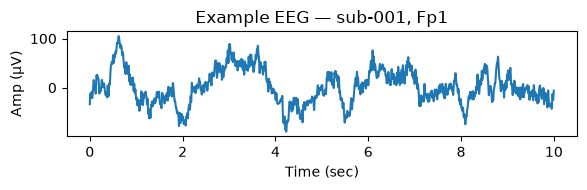

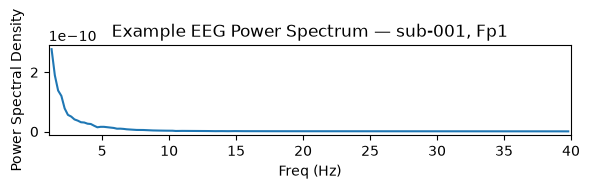

In [86]:
sample_file = preprocessed_files[0]

raw = mne.io.read_raw_eeglab(
    sample_file,
    preload=True,
    verbose="ERROR"
)

print(raw)
print("Sampling freq:", raw.info["sfreq"], "Hz")
print("Duration:", raw.times[-1], "seconds")
print("Channels:", raw.ch_names)

data = raw.get_data(
    picks="Fp1",
    start=0,
    stop=int(10 * raw.info["sfreq"])
)

times = raw.times[:data.shape[1]]

plt.figure(figsize=(6, 2))
plt.plot(times, data[0] * 1e6)
plt.xlabel("Time (sec)")
plt.ylabel("Amp (µV)")
plt.title("Example EEG — sub-001, Fp1")
plt.tight_layout()
plt.show()

spectrum = raw.compute_psd(
    method="welch",
    fmin=1,
    fmax=40,
    verbose="ERROR"
)

psds, freqs = spectrum.get_data(return_freqs=True)

plt.figure(figsize=(6, 2))
plt.plot(freqs, psds[0])
plt.xlabel("Freq (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("Example EEG Power Spectrum — sub-001, Fp1")
plt.xlim(1, 40)
plt.tight_layout()
plt.show()

In [87]:
def get_bandpower(file_path):
    
    raw = mne.io.read_raw_eeglab(file_path, preload=True)
    spectrum = raw.compute_psd(method="welch", fmin=1, fmax=40)
    psds, freqs = spectrum.get_data(return_freqs=True)
    
    features = {}
    for channel_index, channel_name in enumerate(raw.ch_names):
        for band_name, (low, high) in BANDS.items():
            mask = ((freqs >= low) & (freqs < high))
            power = psds[channel_index, mask].mean()
            features[f"{channel_name}_{band_name}"] = np.log10(power + 1e-12)
    
    return features

In [88]:
%%capture --no-stdout
rows = []

for i, file_path in enumerate(preprocessed_files):
    participant_id = file_path.parts[-3]
    participant_features = get_bandpower(file_path)
    participant_features["participant_id"] = participant_id
    rows.append(participant_features)

features_df = pd.DataFrame(rows)

Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Effective wind

In [89]:
model_df = features_df.merge(participants, on="participant_id", how="inner")

print("\nDiagnostic groups:")
print(model_df["Group"].value_counts())


Diagnostic groups:
Group
A    36
C    29
F    23
Name: count, dtype: int64


In [90]:
ad_cn = model_df[model_df["Group"].isin(["A", "C"])].copy()

feature_cols = [
    column
    for column in ad_cn.columns
    if column not in [
        "participant_id",
        "Gender",
        "Age",
        "Group",
        "MMSE"
    ]
]

X = ad_cn[feature_cols]
y = ad_cn["Group"]

In [91]:
cv = StratifiedKFold(n_splits=5, random_state=RANDOM_STATE, shuffle=True)

models = {
    
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(probability=True,random_state=RANDOM_STATE))
    ]),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, pos_label="A", zero_division=0),
    "recall": make_scorer(recall_score, pos_label="A", zero_division=0),
    "f1": make_scorer(f1_score, pos_label="A", zero_division=0),
    "roc_auc": "roc_auc"
}

results = []
for model_name, model in models.items():
    
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, return_train_score=False, n_jobs=-1)
    
    results.append({
        "Model": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Accuracy SD": scores["test_accuracy"].std(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

results_df = pd.DataFrame(results)
display(
    results_df.style.format({
        "Accuracy": "{:.3f}",
        "Accuracy SD": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}",
        "ROC-AUC": "{:.3f}"
    })
)

/Users/suhanibhanvadia/.pyenv/versions/3.12.11/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/suhanibhanvadia/.pyenv/versions/3.12.11/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/suhanibhanvadia/.pyenv/versions/3.12.11/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/suhanibhanvadia/.pyenv/versions/3.12.11/lib/python3.12/site-packages/

,Model,Accuracy,Accuracy SD,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.769,0.069,0.786,0.800,0.779,0.838
1,SVM,0.754,0.058,0.770,0.800,0.773,0.866
2,Random Forest,0.769,0.069,0.830,0.743,0.771,0.907


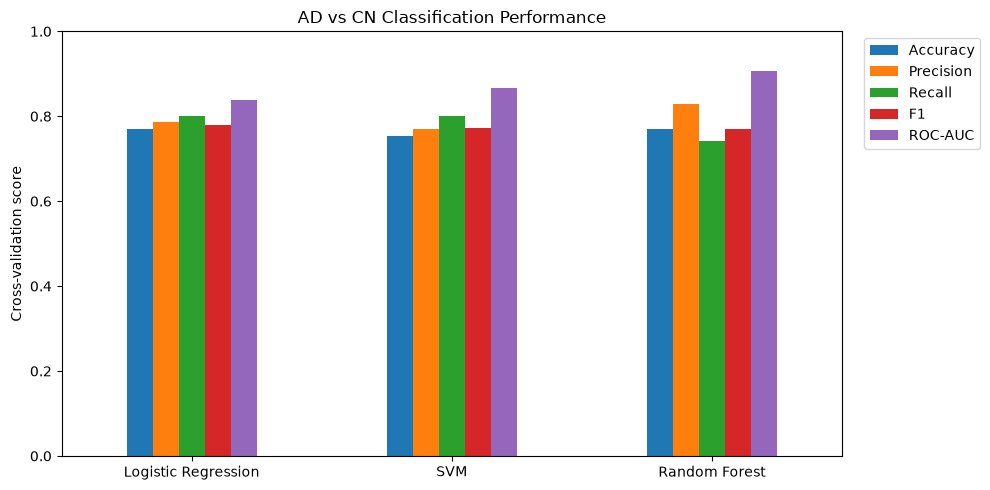

In [92]:
metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]

ax = results_df.set_index("Model")[metrics_to_plot].plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_ylabel("Cross-validation score")
ax.set_xlabel("")
ax.set_title("AD vs CN Classification Performance")
ax.set_ylim(0, 1)

plt.xticks(rotation=0)
plt.legend( bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.show()

In [93]:
majority_class = y.value_counts().max()
baseline_accuracy = (majority_class / len(y))

print("Majority-class baseline accuracy: ", f"{baseline_accuracy:.3f}")

Majority-class baseline accuracy:  0.554


In [94]:
best_model_name = (results_df.sort_values("ROC-AUC", ascending=False).iloc[0]["Model"])
best_model = models[best_model_name]

print("Best model based on mean cross-validated ROC-AUC:", best_model_name)

Best model based on mean cross-validated ROC-AUC: Random Forest


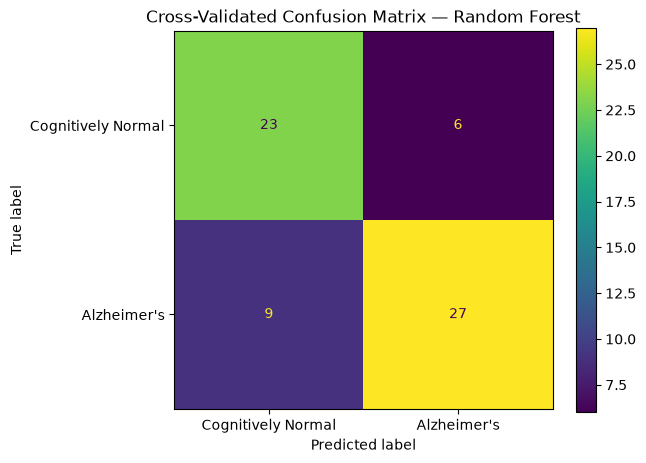

In [95]:
best_predictions = cross_val_predict(best_model, X, y, cv=cv)
cm = confusion_matrix( y, best_predictions, labels=["C", "A"])


ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Cognitively Normal", "Alzheimer's"]).plot()
plt.title(f"Cross-Validated Confusion Matrix — {best_model_name}")
plt.tight_layout()

plt.show()

In [96]:
logistic_model = models["Logistic Regression"]
logistic_model.fit(X, y)

coefficients = pd.Series(
    logistic_model.named_steps["classifier"].coef_[0],
    index=X.columns
)

feature_importance = pd.DataFrame({
    "feature": coefficients.index,
    "coefficient": coefficients.values,
    "importance": coefficients.abs().values
})

feature_importance = (feature_importance.sort_values("importance", ascending=False))

In [97]:
feature_importance["channel"] = (feature_importance["feature"].str.rsplit("_",n=1).str[0])
feature_importance["band"] = (feature_importance["feature"].str.rsplit("_",n=1).str[1])
feature_importance.head()

,feature,coefficient,importance,channel,band
38,O2_alpha,0.889650,0.889650,O2,alpha
59,T5_beta,0.820671,0.820671,T5,beta
43,F7_beta,-0.795646,0.795646,F7,beta
55,T4_beta,-0.755231,0.755231,T4,beta
39,O2_beta,0.715531,0.715531,O2,beta


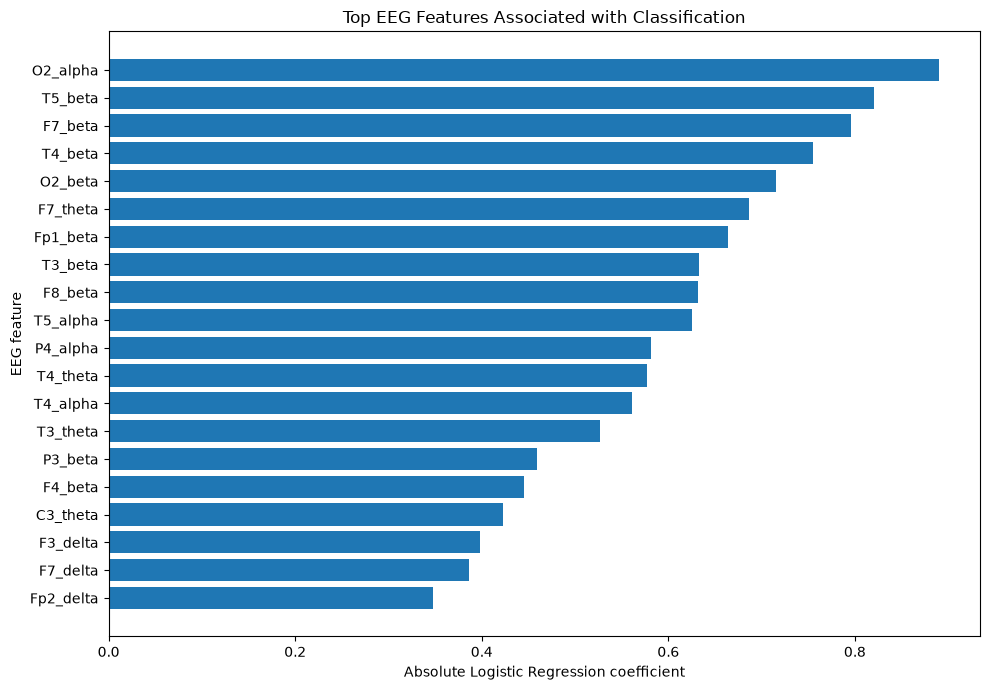

In [98]:
top_features = (feature_importance.head(20).sort_values("importance"))

plt.figure(figsize=(10, 7))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Absolute Logistic Regression coefficient")
plt.ylabel("EEG feature")
plt.title("Top EEG Features Associated with Classification")
plt.tight_layout()

plt.show()

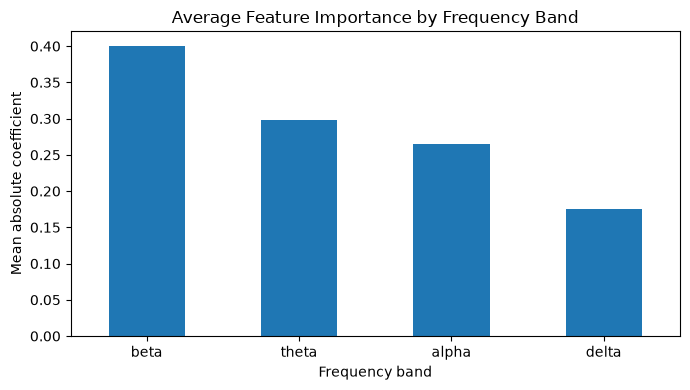

In [99]:
band_importance = (feature_importance.groupby("band")["importance"].mean().sort_values(ascending=False))

plt.figure(figsize=(7, 4))
band_importance.plot(kind="bar")
plt.ylabel("Mean absolute coefficient")
plt.xlabel("Frequency band")
plt.title("Average Feature Importance by Frequency Band")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

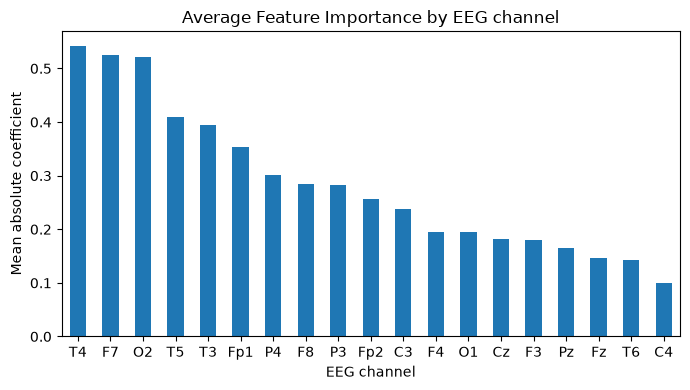

In [100]:
channel_importance = (feature_importance.groupby("channel")["importance"].mean().sort_values(ascending=False))

plt.figure(figsize=(7, 4))
channel_importance.plot(kind="bar")
plt.ylabel("Mean absolute coefficient")
plt.xlabel("EEG channel")
plt.title("Average Feature Importance by EEG channel")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()